### GradCAM Visualization

In [5]:
from pathlib import Path
import csv
import random
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from IPython.display import display
from torchvision import models, transforms

### Paths

In [6]:
DATA_DIR = Path("data")
MODEL_PATH = Path("resnet50_model.pth")
IMAGE_SIZE = 224

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("Model found:", MODEL_PATH.exists())

Device: cpu
Model found: True


### Load ResNet50

In [8]:
resnet_model = models.resnet50(weights=None)
resnet_model.fc = nn.Linear(
    resnet_model.fc.in_features,
    2
)

saved_weights = torch.load(
    MODEL_PATH,
    map_location=device
)

resnet_model.load_state_dict(saved_weights)
resnet_model = resnet_model.to(device)
resnet_model.eval()
print("Model loaded.")

Model loaded.


### Validation transform

In [9]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Select one image

True label: AI


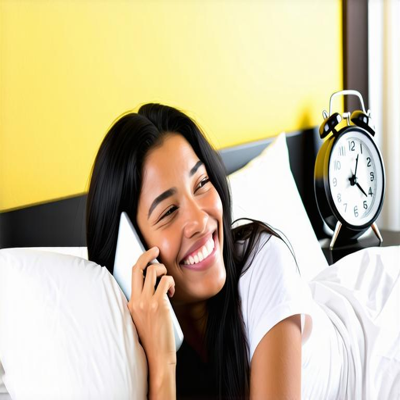

In [10]:
csv_path = DATA_DIR / "train.csv"

with open(csv_path, "r", encoding="utf-8") as file:
    image_rows = list(csv.DictReader(file))

random.seed(42)
sample = random.choice(image_rows)

image_path = DATA_DIR / sample["file_name"]
true_label = int(sample["label"])

class_names = {
    0: "Real",
    1: "AI"
}

image = Image.open(image_path).convert("RGB")

print("True label:", class_names[true_label])
display(image.resize((400, 400)))

### Prepare image and hooks

In [11]:
input_tensor = val_transform(image)
input_tensor = input_tensor.unsqueeze(0).to(device)

saved_activations = None
saved_gradients = None


def save_layer_output(module, inputs, output):
    global saved_activations
    saved_activations = output

    def save_gradient(gradient):
        global saved_gradients
        saved_gradients = gradient

    output.register_hook(save_gradient)


target_layer = resnet_model.layer4[-1]

hook = target_layer.register_forward_hook(
    save_layer_output
)

### Prediction

In [12]:
resnet_model.zero_grad()
output = resnet_model(input_tensor)
probabilities = torch.softmax(output, dim=1)
predicted_label = output.argmax(dim=1).item()
confidence = probabilities[0, predicted_label].item()
print("True label:", class_names[true_label])
print("Predicted label:", class_names[predicted_label])
print(f"Confidence: {confidence * 100:.2f}%")

True label: AI
Predicted label: AI
Confidence: 98.54%


### Create GradCAM

In [13]:
score = output[0, predicted_label]
score.backward()
channel_weights = saved_gradients.mean(
    dim=(2, 3),
    keepdim=True
)

cam = (
    channel_weights * saved_activations
).sum(dim=1)

cam = torch.relu(cam)

cam = torch.nn.functional.interpolate(
    cam.unsqueeze(1),
    size=(224, 224),
    mode="bilinear",
    align_corners=False
)

cam = cam.squeeze()

cam = cam - cam.min()

if cam.max() > 0:
    cam = cam / cam.max()

cam = cam.detach().cpu().numpy()

hook.remove()

### Show GradCAM result

Original image


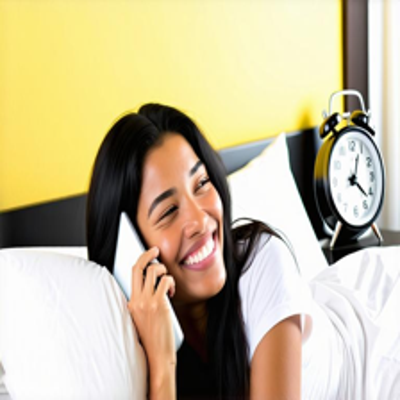

GradCAM result


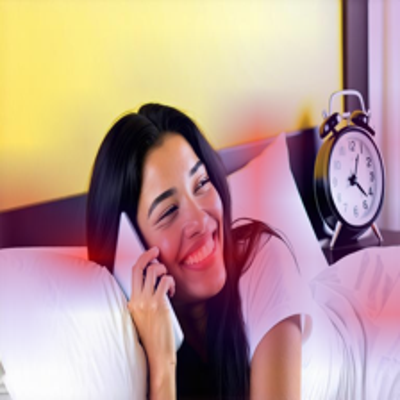

In [15]:
original_image = image.resize((224, 224))

original_array = np.array(
    original_image
).astype(np.float32)

heatmap = np.zeros(
    (224, 224, 3),
    dtype=np.float32
)

heatmap[:, :, 0] = cam * 255
heatmap[:, :, 2] = (1 - cam) * 255

alpha = (cam * 0.6)[..., None]

result = (
    original_array * (1 - alpha)
    + heatmap * alpha
)

result = np.clip(
    result,
    0,
    255
).astype(np.uint8)

gradcam_image = Image.fromarray(result)

print("Original image")
display(original_image.resize((400, 400)))

print("GradCAM result")
display(gradcam_image.resize((400, 400)))

### GradCAM Analysis

The selected image was correctly classified as **AI-generated** with a confidence score of **98.54%**.

The GradCAM visualization highlights the regions that contributed most to the model's prediction. The model focused mainly on the person's face and nearby objects, suggesting that both facial features and surrounding visual patterns influenced the classification.

This visualization improves the interpretability of the model by showing where the network concentrated when distinguishing the image as AI-generated.